In [1]:
import SimpleITK as sitk
import numpy as np
import pyvista as pv
from matplotlib import pyplot as plt
from morphometry.femur import calculate_femoral_torsion

Failed to load image Python extension: '/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?


In [2]:
pv.set_jupyter_backend('trame')

In [3]:
hip = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/t1_tse_tra_Huften_bds_10mm_PA000006.nii.gz')
knee = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset002_AugsburgKnee/labelsTr/6: t1_tse_tra Knie PA000006.nii.gz')

In [4]:
x_ratio = abs(hip.GetSpacing()[2]) / 2 * abs(hip.GetSpacing()[0])

In [5]:
hip_np = sitk.GetArrayFromImage(hip)
knee_np = sitk.GetArrayFromImage(knee)

p = pv.Plotter()
p.add_mesh(pv.PolyData(np.argwhere(hip_np) * np.array([x_ratio, 1, 1])))
p.show()

In [6]:
# Code expects superior - inferior axis to be low - high, i.e. 0 is the most proximal slice. 
# In Augsburg Dataset, this is oppsoite, so we flip the axis
hip_np = hip_np[::-1]
# Code also expects anterior - posterior axis to be low - high, i.e. 0 is the most anterior slice.
# In Augsburg Dataset, this is also opposite, so we flip the axis
hip_np = hip_np[:, ::-1]

In [7]:
hip_np.shape, knee_np.shape

((19, 324, 384), (38, 324, 384))

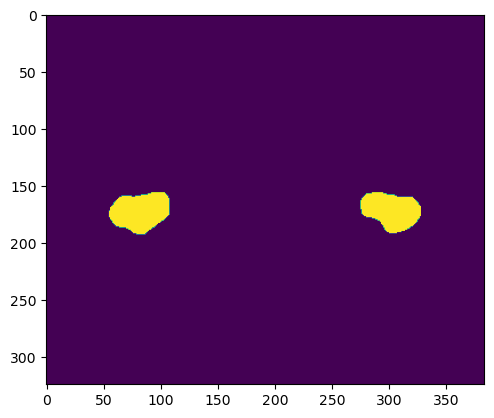

In [8]:
plt.imshow(hip_np[10])

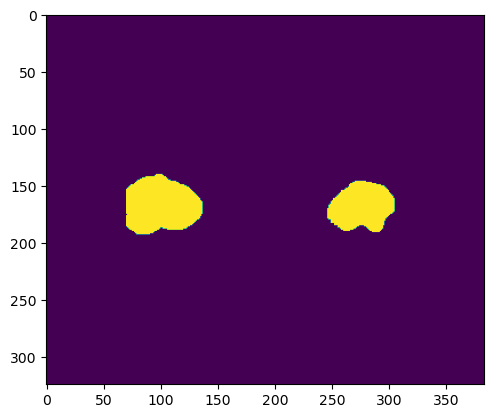

In [9]:
plt.imshow(knee_np[10])

In [10]:
left_hip = hip_np[:, :, :hip_np.shape[2]//2]
right_hip = hip_np[:, :, hip_np.shape[2]//2:]

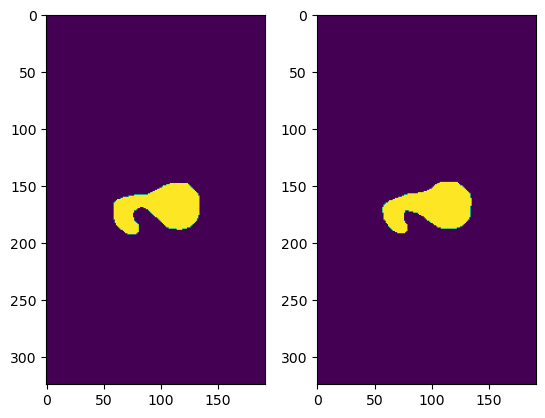

In [11]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(left_hip[7])
ax[1].imshow(right_hip[7][:, ::-1])
plt.show()

In [12]:
left_knee = knee_np[:, :, :knee_np.shape[2]//2]
right_knee = knee_np[:, :, knee_np.shape[2]//2:]

from morphometry.hip import get_femoral_head_center
from skimage import measure
from morphometry.utils import points_on_circle

r, center, layer_high, layer_low = get_femoral_head_center(left_hip, side='left', segmentation_label=1, return_layers=True, x_ratio=x_ratio)
center = center.astype(np.int16)

layer_selected = None
fig, ax = plt.subplots(left_hip.shape[0], 1, figsize=(10, 10 * left_hip.shape[0]))
for n in range(left_hip.shape[0] - 1, 0, -1):
    contour_length = len(measure.find_contours(left_hip[n], 0.8))
    on_circle = points_on_circle(left_hip[n], r * 2, center[1:])
    ax[n].imshow(left_hip[n])
    ax[n].add_patch(plt.Circle((center[2], center[1]), r * 2, color='r', fill=False))

plt.show()

pc = np.argwhere(left_hip).astype(np.float32)
pc[:, 0] *= hip.GetSpacing()[2]
p = pv.Plotter()
p.add_mesh(pv.PolyData(pc))
p.add_mesh(pv.Sphere(radius=r, center=center))
p.show()

Center: [  1 167 115]
Layer selected: 7
[  7 167 115] [  7 156  35]


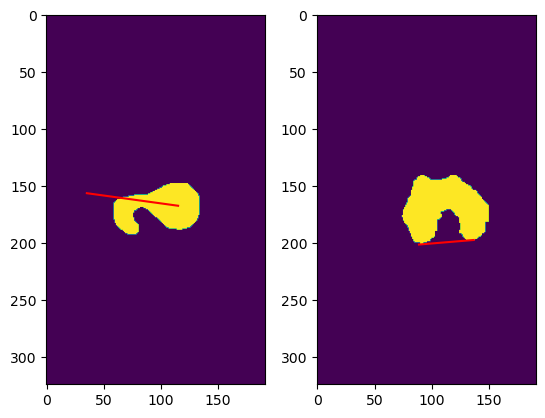

12.592718200785795

In [13]:
calculate_femoral_torsion(left_hip, left_knee, side='left', segmentation_label=1, x_ratio=x_ratio, plot=True)

Center: [  1 167  80]
Center new: [  1 167 112]
Layer selected: 7
[  7 167  80] [  7 159 160]


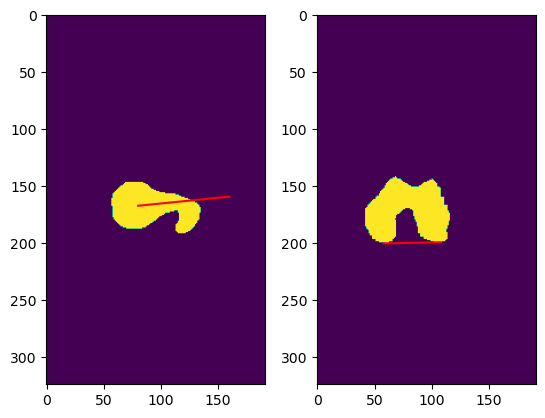

4.564830299324478

In [14]:
calculate_femoral_torsion(right_hip, right_knee, side='right', segmentation_label=1, x_ratio=x_ratio, plot=True)